**AIVLE School 미니프로젝트**
### **공공데이터를 활용한 <span style="color:darkgreen">미세먼지 농도</span> 예측**
---

#### **<span style="color:red">[미션 안내]</span>**
* 개인 미션: 미세먼지 농도를 예측하는 머신러닝 모델을 만드세요. ([2-1]부터 [2-10], [3-1]부터 [3-6] 까지 미션 수행)
* 조별 미션: 개인 미션 수행한 내용에 대해 토론하여 발표 준비를 해주세요.

#### **<span style="color:red">[주피터 노트북 파일 안내]</span>**
1. 탐색적 데이터 분석(solution).ipynb: 미션 수행 대상 아님. 제공된 solution을 참고하여 [2-1]부터의 미션 수행을 위한 탐색적 데이터 분석 진행</br>
2. 데이터 전처리.ipynb: [2-1]부터 [2-8] 까지 미션 수행 대상</br>
3. 모델링(머신러닝).ipynb: [3-1]부터 [3-2] 까지 미션 수행 대상. [4-1]~[4-4]는 선택 사항임</br>

#### **<span style="color:red">[데이터 설명]</span>**

* air_2021.csv : 2021년 미세먼지 데이터
* air_2022.csv : 2022년 미세먼지 데이터
* weather_2021.csv : 2021년 날씨 데이터
* weather_2022.csv : 2022년 날씨 데이터
* 학습 데이터: 2021년의 미세먼지 농도 데이터, 테스트 데이터: 2022년의 미세먼지 농도 데이터

# [Step 1] 탐색적 데이터 분석

#### **<span style="color:blue">[1-1] 필요한 라이브러리 설치</span>**

In [7]:
# 필요한 라이브러리 설치 및 임포트
#%pip install pandas seaborn

import pandas as pd
import seaborn as sns
import matplotlib as plt

---

#### **<span style="color:blue">[1-2] 미세먼지 데이터 불러오기</span>**

* Pandas 라이브러리를 활용해서 'air_2021.csv'파일을 'air_21' 변수에, 'air_2022.csv'파일을 'air_22' 변수에 저장하고 그 데이터를 확인하세요.
* 구분자(sep) : ','
* encoder = 'utf-8'
* index_col = 0

In [11]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 'air_2021.csv'파일을 'air_21' 변수에, 'air_2022.csv'파일을 'air_22' 변수에 저장
air_21 = pd.read_csv('air_2021.csv', sep=',', encoding='utf-8', index_col=0)
air_22 = pd.read_csv('air_2022.csv', sep=',', encoding='utf-8', index_col=0)


In [12]:
# air_21 데이터의 head 확인
air_21.head()

,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
0,서울 종로구,도시대기,111123,종로구,2021100101,0.003,0.6,0.002,0.039,31.0,18.0,서울 종로구 종로35가길 19
1,서울 종로구,도시대기,111123,종로구,2021100102,0.003,0.6,0.002,0.035,27.0,16.0,서울 종로구 종로35가길 19
2,서울 종로구,도시대기,111123,종로구,2021100103,0.003,0.6,0.002,0.033,28.0,18.0,서울 종로구 종로35가길 19
3,서울 종로구,도시대기,111123,종로구,2021100104,0.003,0.6,0.002,0.030,26.0,16.0,서울 종로구 종로35가길 19
4,서울 종로구,도시대기,111123,종로구,2021100105,0.003,0.5,0.003,0.026,26.0,16.0,서울 종로구 종로35가길 19


In [13]:
air_21.tail(30)

,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
8730,서울 종로구,도시대기,111123,종로구,2021092919,0.003,0.4,0.016,0.017,11.0,8.0,서울 종로구 종로35가길 19
8731,서울 종로구,도시대기,111123,종로구,2021092920,0.003,0.5,0.014,0.018,15.0,9.0,서울 종로구 종로35가길 19
8732,서울 종로구,도시대기,111123,종로구,2021092921,0.003,0.5,0.006,0.024,18.0,13.0,서울 종로구 종로35가길 19
8733,서울 종로구,도시대기,111123,종로구,2021092922,0.003,0.7,0.005,0.025,15.0,9.0,서울 종로구 종로35가길 19
8734,서울 종로구,도시대기,111123,종로구,2021092923,0.003,0.5,0.007,0.021,14.0,8.0,서울 종로구 종로35가길 19
8735,서울 종로구,도시대기,111123,종로구,2021092924,0.003,0.5,0.004,0.021,11.0,6.0,서울 종로구 종로35가길 19
8736,서울 종로구,도시대기,111123,종로구,2021093001,0.003,0.4,0.004,0.019,13.0,6.0,서울 종로구 종로35가길 19
8737,서울 종로구,도시대기,111123,종로구,2021093002,0.003,0.4,0.005,0.018,13.0,7.0,서울 종로구 종로35가길 19
8738,서울 종로구,도시대기,111123,종로구,2021093003,0.003,0.4,0.006,0.015,14.0,11.0,서울 종로구 종로35가길 19
8739,서울 종로구,도시대기,111123,종로구,2021093004,0.003,0.4,0.006,0.013,15.0,10.0,서울 종로구 종로35가길 19


In [14]:
# air_21 데이터의 shape 확인
air_21.shape

(8760, 12)

In [15]:
# air_22 데이터의 head 확인
air_22.head()


,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
0,서울 종로구,도시대기,111123,종로구,2022010101,0.003,0.4,0.026,0.016,23.0,12.0,서울 종로구 종로35가길 19
1,서울 종로구,도시대기,111123,종로구,2022010102,0.003,0.4,0.022,0.020,20.0,9.0,서울 종로구 종로35가길 19
2,서울 종로구,도시대기,111123,종로구,2022010103,0.003,0.5,0.014,0.028,20.0,9.0,서울 종로구 종로35가길 19
3,서울 종로구,도시대기,111123,종로구,2022010104,0.003,0.5,0.016,0.027,19.0,10.0,서울 종로구 종로35가길 19
4,서울 종로구,도시대기,111123,종로구,2022010105,0.003,0.5,0.005,0.040,24.0,11.0,서울 종로구 종로35가길 19


In [16]:
air_22.tail(10)


,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
2150,서울 종로구,도시대기,111123,종로구,2022033115,0.003,0.3,0.050,0.011,16.0,10.0,서울 종로구 종로35가길 19
2151,서울 종로구,도시대기,111123,종로구,2022033116,0.002,0.3,0.049,0.009,14.0,7.0,서울 종로구 종로35가길 19
2152,서울 종로구,도시대기,111123,종로구,2022033117,0.003,0.4,0.045,0.010,10.0,5.0,서울 종로구 종로35가길 19
2153,서울 종로구,도시대기,111123,종로구,2022033118,0.003,0.4,0.043,0.011,9.0,6.0,서울 종로구 종로35가길 19
2154,서울 종로구,도시대기,111123,종로구,2022033119,0.002,0.4,0.044,0.010,10.0,9.0,서울 종로구 종로35가길 19
2155,서울 종로구,도시대기,111123,종로구,2022033120,0.002,0.4,0.036,0.017,11.0,8.0,서울 종로구 종로35가길 19
2156,서울 종로구,도시대기,111123,종로구,2022033121,0.002,0.4,0.032,0.018,10.0,7.0,서울 종로구 종로35가길 19
2157,서울 종로구,도시대기,111123,종로구,2022033122,0.003,0.3,0.038,0.013,11.0,5.0,서울 종로구 종로35가길 19
2158,서울 종로구,도시대기,111123,종로구,2022033123,0.003,0.3,0.036,0.015,11.0,5.0,서울 종로구 종로35가길 19
2159,서울 종로구,도시대기,111123,종로구,2022033124,0.002,0.4,0.033,0.017,9.0,5.0,서울 종로구 종로35가길 19


In [17]:
# air_22 데이터의 shape 확인
air_22.shape


(2160, 12)

---

#### **<span style="color:blue">[1-3] 날씨 데이터 불러오기</span>**

* Pandas 라이브러리를 활용해서 'weather_2021.csv'파일을 'weather_21' 변수에, 'weather_2022.csv'파일을 'weather_22' 변수에 저장하고 그 데이터를 확인하세요.
* 구분자(sep) : ','
* encoder = 'cp949'

In [21]:
weather_21 = pd.read_csv('weather_2021.csv', 
                         sep=',', encoding='cp949', index_col=0)

weather_22 = pd.read_csv('weather_2022.csv', 
                         sep=',', encoding='cp949', index_col=0)


In [22]:
# 미세먼지 데이터와 같이 날씨 데이터의 head, shape 등을 확인
weather_21.head()


,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
지점,,,,,,,,,,,,,,,,,,,,,
108,서울,2021-01-01 01:00,-8.7,NaN,NaN,NaN,2.4,NaN,270.0,NaN,...,NaN,2000,NaN,NaN,-6.9,NaN,-1.0,-0.8,0.3,1.6
108,서울,2021-01-01 02:00,-9.1,NaN,NaN,NaN,1.6,NaN,270.0,NaN,...,NaN,2000,NaN,NaN,-7.1,NaN,-1.1,-0.8,0.3,1.6
108,서울,2021-01-01 03:00,-9.3,NaN,NaN,NaN,1.1,NaN,250.0,NaN,...,NaN,2000,NaN,NaN,-7.3,NaN,-1.2,-0.9,0.3,1.6
108,서울,2021-01-01 04:00,-9.3,NaN,NaN,NaN,0.3,NaN,0.0,NaN,...,NaN,2000,NaN,NaN,-7.5,NaN,-1.3,-1.0,0.2,1.5
108,서울,2021-01-01 05:00,-9.7,NaN,NaN,NaN,1.9,NaN,20.0,NaN,...,NaN,2000,NaN,NaN,-7.6,NaN,-1.3,-1.0,0.2,1.5


In [23]:
weather_21.shape

(8759, 37)

In [24]:
weather_22.head()

,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
지점,,,,,,,,,,,,,,,,,,,,,
108,서울,2022-01-01 00:00,-8.5,NaN,NaN,NaN,1.9,NaN,320,NaN,...,NaN,2000,NaN,NaN,-7.0,NaN,-1.0,-1.0,-0.2,1.0
108,서울,2022-01-01 01:00,-9.2,NaN,NaN,NaN,1.8,NaN,270,NaN,...,NaN,2000,NaN,NaN,-7.2,NaN,-1.1,-1.1,-0.2,1.0
108,서울,2022-01-01 02:00,-9.5,NaN,NaN,NaN,1.2,NaN,270,NaN,...,NaN,2000,NaN,NaN,-7.5,NaN,-1.3,-1.2,-0.2,1.0
108,서울,2022-01-01 03:00,-9.3,NaN,NaN,NaN,1.4,NaN,290,NaN,...,NaN,2000,NaN,NaN,-7.6,NaN,-1.4,-1.2,-0.2,1.0
108,서울,2022-01-01 04:00,-9.6,NaN,NaN,NaN,1.7,NaN,340,NaN,...,NaN,2000,NaN,NaN,-7.6,NaN,-1.4,-1.3,-0.3,1.0


In [25]:
weather_22.shape

(2160, 37)

---

#### **<span style="color:blue">[1-4] 데이터 변수 확인</span>**

In [28]:
# 각 데이터프레임의 info 확인
air_21.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 0 to 8759
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역      8760 non-null   object 
 1   망       8760 non-null   object 
 2   측정소코드   8760 non-null   int64  
 3   측정소명    8760 non-null   object 
 4   측정일시    8760 non-null   int64  
 5   SO2     8648 non-null   float64
 6   CO      8680 non-null   float64
 7   O3      8663 non-null   float64
 8   NO2     8680 non-null   float64
 9   PM10    8655 non-null   float64
 10  PM25    8663 non-null   float64
 11  주소      8760 non-null   object 
dtypes: float64(6), int64(2), object(4)
memory usage: 889.7+ KB


In [29]:
air_22.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2160 entries, 0 to 2159
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역      2160 non-null   object 
 1   망       2160 non-null   object 
 2   측정소코드   2160 non-null   int64  
 3   측정소명    2160 non-null   object 
 4   측정일시    2160 non-null   int64  
 5   SO2     2139 non-null   float64
 6   CO      2139 non-null   float64
 7   O3      2139 non-null   float64
 8   NO2     2139 non-null   float64
 9   PM10    2122 non-null   float64
 10  PM25    2135 non-null   float64
 11  주소      2160 non-null   object 
dtypes: float64(6), int64(2), object(4)
memory usage: 219.4+ KB


In [30]:
weather_21.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8759 entries, 108 to 108
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   지점명            8759 non-null   object 
 1   일시             8759 non-null   object 
 2   기온(°C)         8759 non-null   float64
 3   기온 QC플래그       0 non-null      float64
 4   강수량(mm)        949 non-null    float64
 5   강수량 QC플래그      1763 non-null   float64
 6   풍속(m/s)        8757 non-null   float64
 7   풍속 QC플래그       2 non-null      float64
 8   풍향(16방위)       8757 non-null   float64
 9   풍향 QC플래그       2 non-null      float64
 10  습도(%)          8759 non-null   int64  
 11  습도 QC플래그       0 non-null      float64
 12  증기압(hPa)       8759 non-null   float64
 13  이슬점온도(°C)      8759 non-null   float64
 14  현지기압(hPa)      8759 non-null   float64
 15  현지기압 QC플래그     0 non-null      float64
 16  해면기압(hPa)      8759 non-null   float64
 17  해면기압 QC플래그     0 non-null      float64
 18  일조(hr)      

In [31]:
weather_22.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2160 entries, 108 to 108
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   지점명            2160 non-null   object 
 1   일시             2160 non-null   object 
 2   기온(°C)         2160 non-null   float64
 3   기온 QC플래그       0 non-null      float64
 4   강수량(mm)        81 non-null     float64
 5   강수량 QC플래그      382 non-null    float64
 6   풍속(m/s)        2160 non-null   float64
 7   풍속 QC플래그       0 non-null      float64
 8   풍향(16방위)       2160 non-null   int64  
 9   풍향 QC플래그       0 non-null      float64
 10  습도(%)          2160 non-null   int64  
 11  습도 QC플래그       0 non-null      float64
 12  증기압(hPa)       2160 non-null   float64
 13  이슬점온도(°C)      2160 non-null   float64
 14  현지기압(hPa)      2160 non-null   float64
 15  현지기압 QC플래그     0 non-null      float64
 16  해면기압(hPa)      2160 non-null   float64
 17  해면기압 QC플래그     0 non-null      float64
 18  일조(hr)      

In [32]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.



---

#### **<span style="color:blue">[1-5] 미세먼지 데이터 분석</span>**

* 데이터 전처리와 모델링을 위해 데이터 분석을 진행해보세요. 시각화 등을 통해 관측치들의 패턴 탐색, 잘못된 자료 탐색, 변수들간의 관계 파악을 할 수 있습니다.

In [36]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # ✅ 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # ✅ 마이너스 깨짐 방지

In [37]:
# air_21,air_22 의 다양한 변수에 대하여 시각화
air_21['측정일시'] = pd.to_datetime(air_21['측정일시'], format='%Y%m%d%H', errors='coerce')
air_22['측정일시'] = pd.to_datetime(air_22['측정일시'], format='%Y%m%d%H', errors='coerce')

In [38]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
air_21['연도'] = air_21['측정일시'].dt.year
air_21['월'] = air_21['측정일시'].dt.month
air_21['일'] = air_21['측정일시'].dt.day
air_21['시간'] = air_21['측정일시'].dt.hour

In [39]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
air_22['연도'] = air_22['측정일시'].dt.year
air_22['월'] = air_22['측정일시'].dt.month
air_22['일'] = air_22['측정일시'].dt.day
air_22['시간'] = air_22['측정일시'].dt.hour

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 2021년 미세먼지 농도 시각화

In [42]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'

/Users/yuserih/env39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


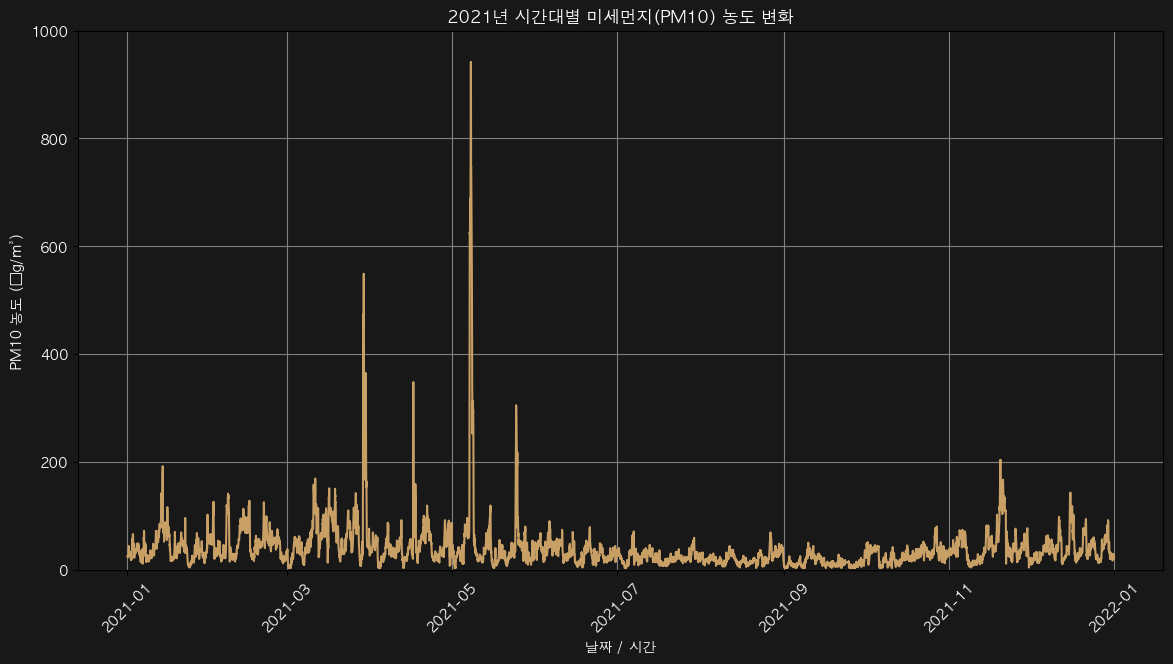

In [43]:
plt.figure(figsize=(14, 7), facecolor='#181818')
ax = sns.lineplot(x='측정일시', y='PM10', data=air_21, color="#c89f65")

plt.title('2021년 시간대별 미세먼지(PM10) 농도 변화', color='white')
plt.xlabel('날짜 / 시간', color='white')
plt.ylabel('PM10 농도 (µg/m³)', color='white')
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
ax.set_facecolor('#181818')
ax.grid(visible=True, color='gray')

plt.ylim(0, 1000)  # ✅ y축 범위 늘림
plt.subplots_adjust(top=0.88)  # ✅ 제목 잘림 방지

plt.show()


## 2022년 미세먼지 농도 시각화

/Users/yuserih/env39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


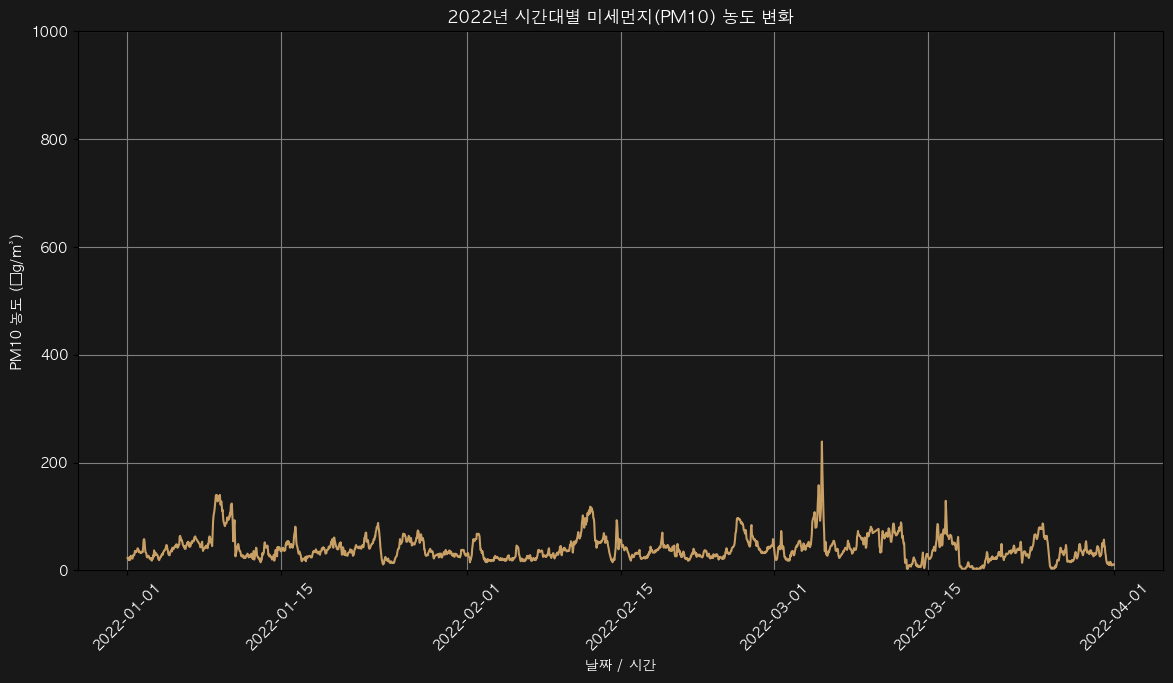

In [45]:
plt.figure(figsize=(14, 7), facecolor='#181818')
ax = sns.lineplot(x='측정일시', y='PM10', data=air_22, color="#c89f65")

plt.title('2022년 시간대별 미세먼지(PM10) 농도 변화', color='white')
plt.xlabel('날짜 / 시간', color='white')
plt.ylabel('PM10 농도 (µg/m³)', color='white')
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
ax.set_facecolor('#181818')
ax.grid(visible=True, color='gray')

plt.ylim(0, 1000)  # ✅ y축 범위 늘림
plt.subplots_adjust(top=0.88)  # ✅ 제목 잘림 방지

plt.show()

In [46]:
print(air_22['측정일시'].min())
print(air_22['측정일시'].max())

2022-01-01 01:00:00
2022-03-31 23:00:00


/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/120229007.py:44: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/yuserih/env39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


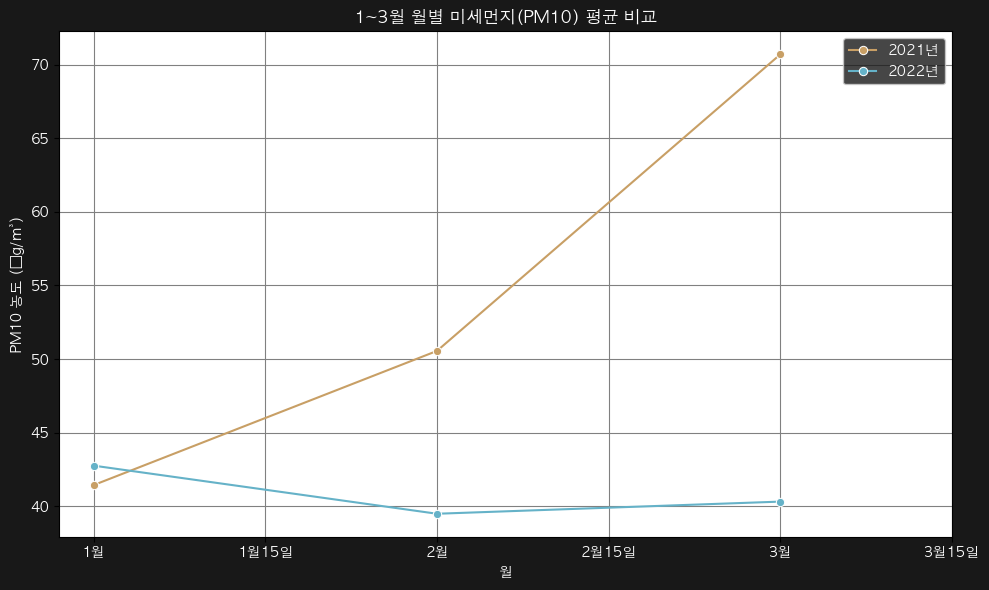

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ✅ 한글 폰트 설정
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'

# ✅ 1~3월 데이터 자르기
air_21_trim = air_21[(air_21['측정일시'] >= '2021-01-01') & (air_21['측정일시'] <= '2021-03-31')].copy()
air_22_trim = air_22[(air_22['측정일시'] >= '2022-01-01') & (air_22['측정일시'] <= '2022-03-31')].copy()

# ✅ 월 추출
air_21_trim['월'] = air_21_trim['측정일시'].dt.month
air_22_trim['월'] = air_22_trim['측정일시'].dt.month

# ✅ 월별 평균 PM10 계산
monthly_21 = air_21_trim.groupby('월')['PM10'].mean().reset_index()
monthly_22 = air_22_trim.groupby('월')['PM10'].mean().reset_index()

# ✅ 연도 태그 추가
monthly_21['연도'] = '2021년'
monthly_22['연도'] = '2022년'

# ✅ 병합
compare_df = pd.concat([monthly_21, monthly_22])

# ✅ 시각화
plt.figure(figsize=(10, 6), facecolor='#181818')
sns.lineplot(x='월', y='PM10', hue='연도', data=compare_df, palette=['#c89f65', '#65b2c8'], marker='o')

plt.title('1~3월 월별 미세먼지(PM10) 평균 비교', color='white')
plt.xlabel('월', color='white')
plt.ylabel('PM10 농도 (µg/m³)', color='white')

# ✅ x축 눈금 위치 + 라벨 수동 지정
tick_pos = [1, 1.5, 2, 2.5, 3, 3.5]
tick_labels = ['1월', '1월15일', '2월', '2월15일', '3월', '3월15일']
plt.xticks(tick_pos, tick_labels, color='white')

plt.yticks(color='white')
plt.grid(True, color='gray')
plt.legend(facecolor='#181818', labelcolor='white')
plt.tight_layout()
plt.show()


# 오염물질별 그래프

In [49]:
pollutants = ['SO2', 'CO', 'O3', 'NO2', 'PM10']

# 각 오염물질별 2021과 2022 중 가장 큰 값 찾기
y_lims = {}
for p in pollutants:
    max_val = max(air_21[p].max(), air_22[p].max())
    y_lims[p] = (0, round(max_val * 1.1))  # 약간 여유 주기

## 2021년 오염물질

/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1615202367.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='시간', y=pollutant, data=air_21, estimator='mean', ci=None, color='#c89f65')
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1615202367.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='시간', y=pollutant, data=air_21, estimator='mean', ci=None, color='#c89f65')
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1615202367.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='시간', y=pollutant, data=air_21, estimator='mean', ci=None, color='#c89f65')
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1615202367.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=

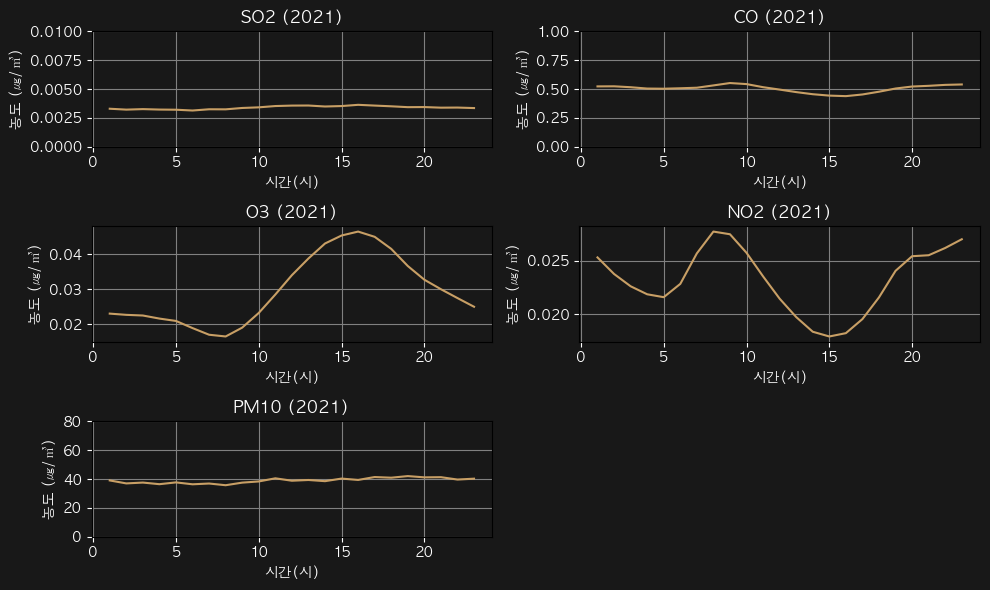

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 오염물질 목록
pollutants = ['SO2', 'CO', 'O3', 'NO2', 'PM10']

# SO2, CO, PM10만 y축 수동 설정
custom_y_lims = {
    'SO2': (0, 0.01),
    'CO': (0, 1.0),
    'PM10': (0, 80)
}

# 시각화 시작
plt.figure(figsize=(10, 6), facecolor='#181818')

for i, pollutant in enumerate(pollutants, 1):
    ax = plt.subplot(3, 2, i, facecolor='#181818')
    sns.lineplot(x='시간', y=pollutant, data=air_21, estimator='mean', ci=None, color='#c89f65')
    plt.title(f'{pollutant} (2021)', color='white')
    plt.xlabel('시간(시)', color='white')
    plt.ylabel('농도 (㎍/㎥)', color='white')
    plt.tick_params(axis='x', colors='white')
    plt.tick_params(axis='y', colors='white')
    ax.grid(visible=True, color='gray')

    # 특정 오염물질은 y축 수동 조정
    if pollutant in custom_y_lims:
        ax.set_ylim(custom_y_lims[pollutant])

plt.tight_layout()
plt.show()

## 2022년 오염물질

/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1308390186.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='시간', y=pollutant, data=air_22, estimator='mean', ci=None, color='#c89f65')
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1308390186.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='시간', y=pollutant, data=air_22, estimator='mean', ci=None, color='#c89f65')
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1308390186.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='시간', y=pollutant, data=air_22, estimator='mean', ci=None, color='#c89f65')
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1308390186.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=

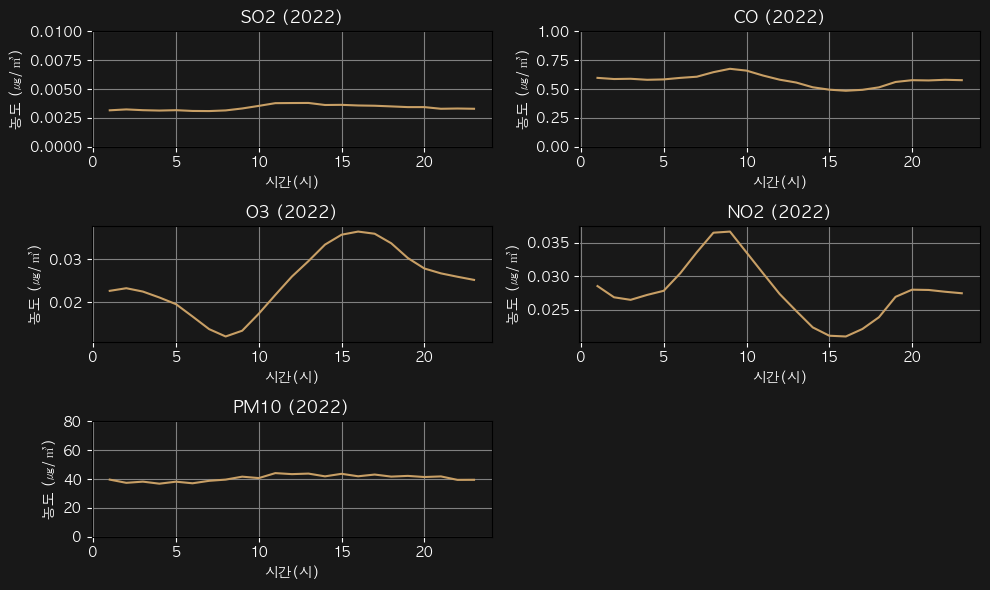

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 대상 오염물질 목록
pollutants = ['SO2', 'CO', 'O3', 'NO2', 'PM10']

# SO2, CO, PM10만 y축 범위 수동 설정
custom_y_lims = {
    'SO2': (0, 0.01),
    'CO': (0, 1.0),
    'PM10': (0, 80)
}

# 시각화 시작
plt.figure(figsize=(10, 6), facecolor='#181818')

for i, pollutant in enumerate(pollutants, 1):
    ax = plt.subplot(3, 2, i, facecolor='#181818')
    sns.lineplot(x='시간', y=pollutant, data=air_22, estimator='mean', ci=None, color='#c89f65')
    plt.title(f'{pollutant} (2022)', color='white')
    plt.xlabel('시간(시)', color='white')
    plt.ylabel('농도 (㎍/㎥)', color='white')
    plt.tick_params(axis='x', colors='white')
    plt.tick_params(axis='y', colors='white')
    ax.grid(visible=True, color='gray')

    # 특정 오염물질은 y축 수동 조정
    if pollutant in custom_y_lims:
        ax.set_ylim(custom_y_lims[pollutant])

plt.tight_layout()
plt.show()

/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1344293585.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1344293585.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/1344293585.py:28: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/yuserih/env39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


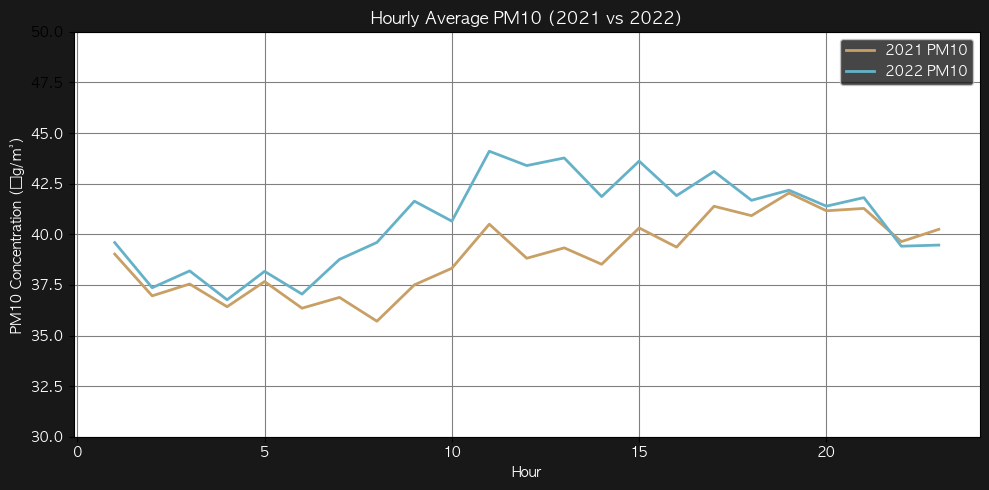

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5), facecolor='#181818')

# 2021년 평균 PM10
sns.lineplot(
    x='시간', y='PM10', data=air_21,
    estimator='mean', ci=None, label='2021 PM10',
    color='#c89f65', linewidth=2
)

# 2022년 평균 PM10
sns.lineplot(
    x='시간', y='PM10', data=air_22,
    estimator='mean', ci=None, label='2022 PM10',
    color='#65b2c8', linewidth=2
)

plt.title('Hourly Average PM10 (2021 vs 2022)', color='white')
plt.xlabel('Hour', color='white')
plt.ylabel('PM10 Concentration (µg/m³)', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(True, color='gray')
plt.legend(loc='upper right', facecolor='#181818', labelcolor='white')
plt.ylim(30, 50)
plt.tight_layout()
plt.show()

## 상관계수 분석 히트맵

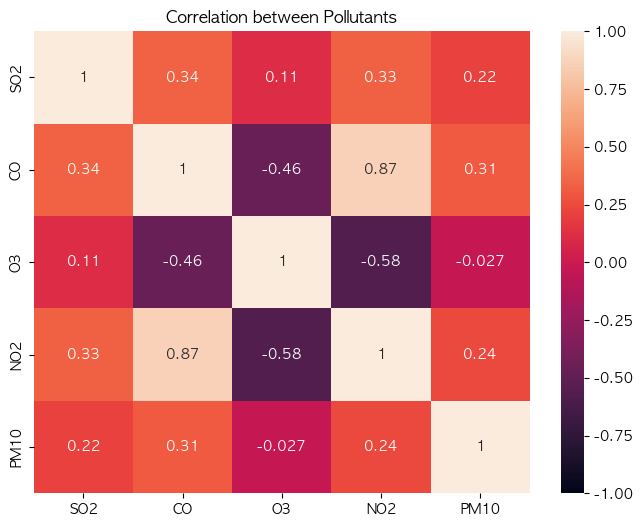

In [56]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
plt.figure(figsize=(8, 6))
sns.heatmap(air_21[pollutants].corr(), annot=True, vmin=-1, vmax=1)
plt.title('Correlation between Pollutants')
plt.show()

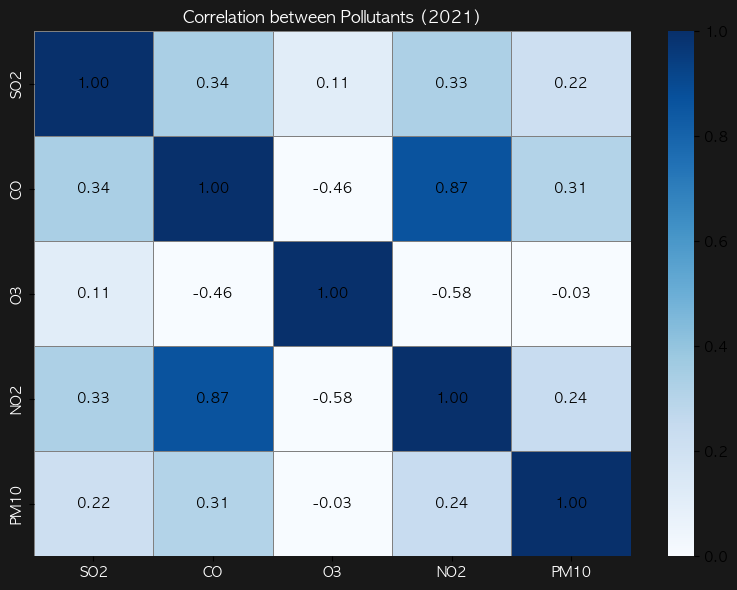

In [57]:
plt.figure(figsize=(8, 6), facecolor='#181818')
sns.heatmap(
    air_21[pollutants].corr(),
    annot=True,
    fmt=".2f",
    cmap='Blues',         # ✅ 단일 색 계열
    vmin=0, vmax=1,       # ✅ 음수 제외 (양의 상관만 강조할 경우)
    annot_kws={"color": "black"},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Correlation between Pollutants (2021)', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

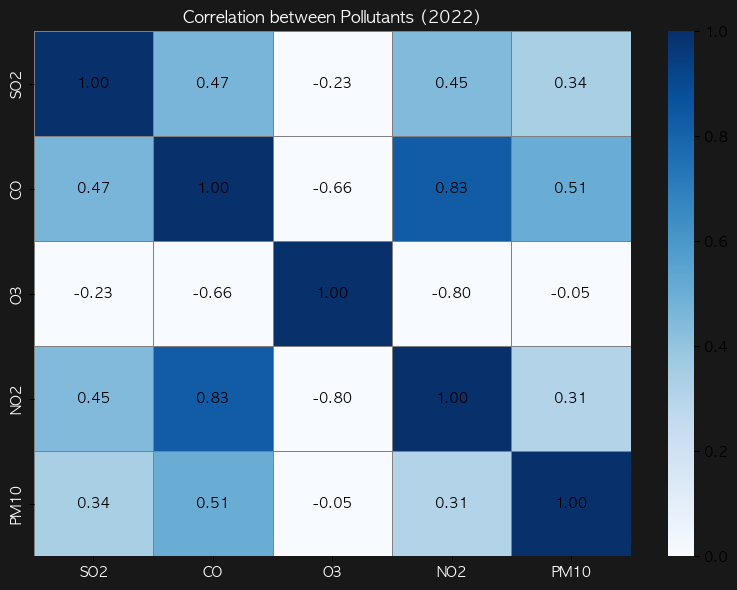

In [58]:
plt.figure(figsize=(8, 6), facecolor='#181818')
sns.heatmap(
    air_22[pollutants].corr(),
    annot=True,
    fmt=".2f",
    cmap='Blues',         # ✅ 같은 색 계열 그라데이션
    vmin=0, vmax=1,       # ✅ 양의 상관계수만 강조
    annot_kws={"color": "black"},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Correlation between Pollutants (2022)', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

In [59]:
# 시각화를 통해 알게된 사실을 정리해봅니다.
# 1. 시간대별 S02, O3, PM10의 변화 형상이 비슷하다
# 2. 상관계수가 적으므로 PM10에 큰 영향을 끼치지 못할 것으로 예상
# 3.

---

#### **<span style="color:blue">[1-6] 날씨 데이터 분석</span>**

In [62]:
# weather_21,weather_22 의 다양한 변수에 대하여 시각화
weather_21['일시'] = pd.to_datetime(weather_21['일시'])
weather_22['일시'] = pd.to_datetime(weather_22['일시'])
weather_21['월'] = weather_21['일시'].dt.month
weather_22['월'] = weather_22['일시'].dt.month

/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_10096/2247050181.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(facecolor='#181818', labelcolor='white', loc='upper right')


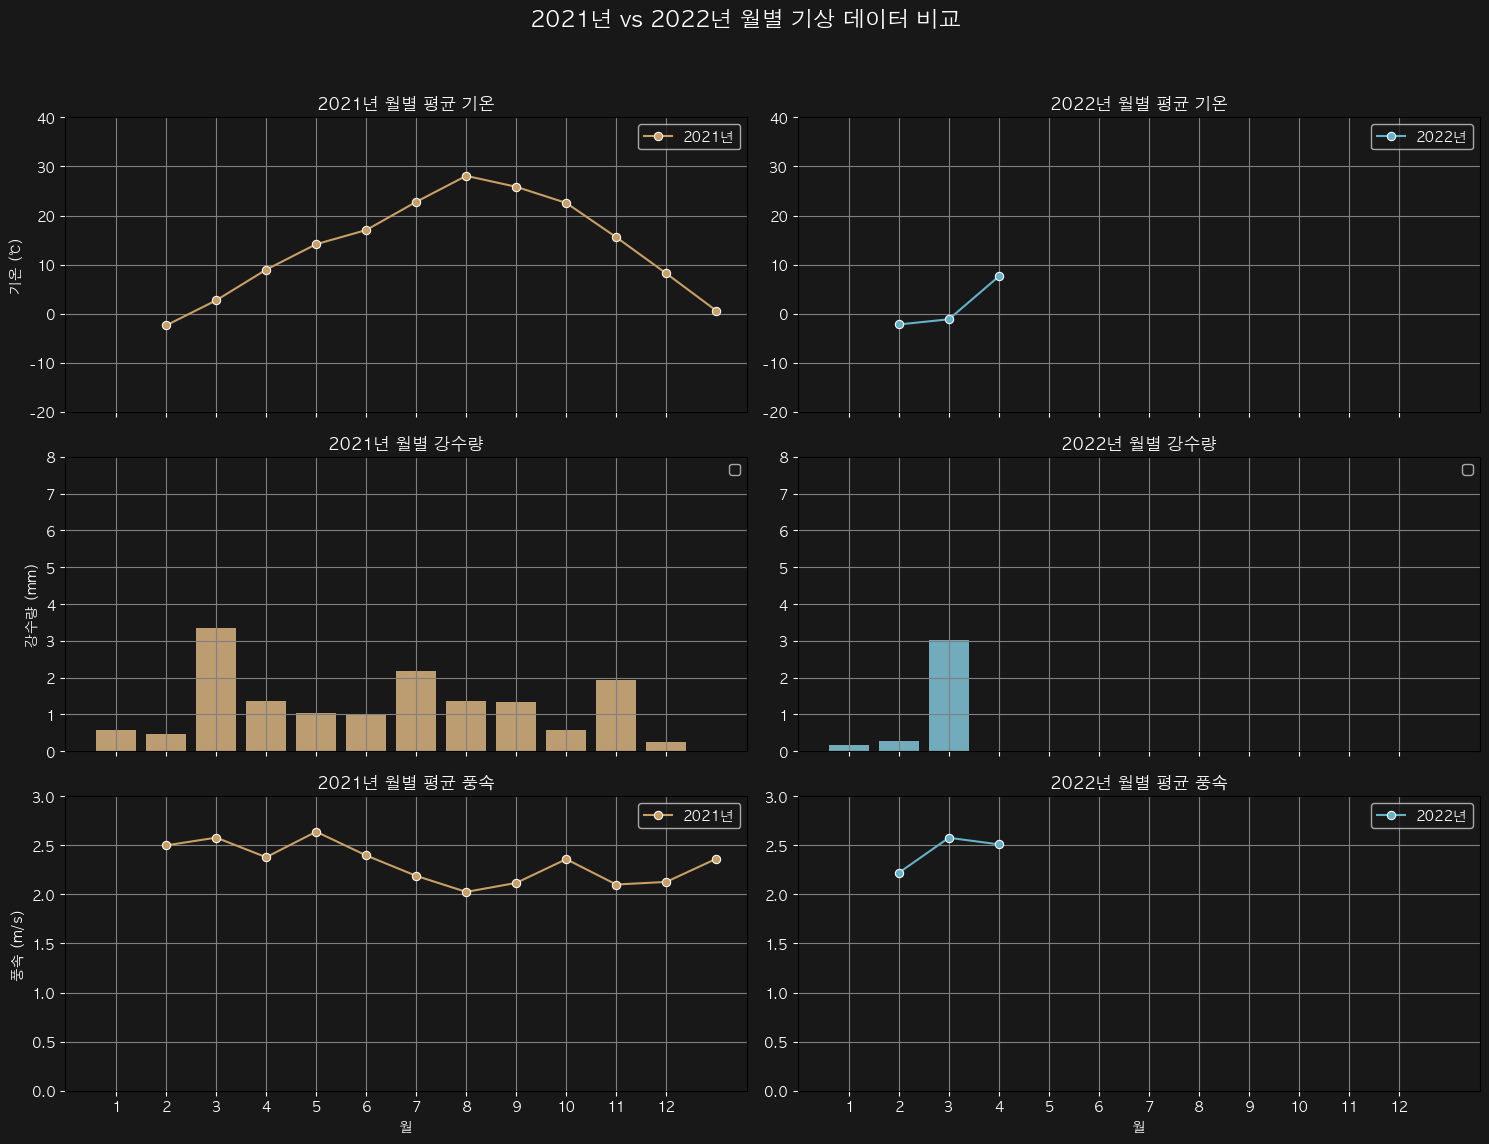

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ✅ 한글 폰트 및 스타일 설정
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'

# ✅ 색상 설정
color_21 = '#c89f65'
color_22 = '#65b2c8'

# ✅ 누락된 월 보정 함수
def ensure_all_months(df, column):
    return df.groupby('월')[column].mean().reindex(range(1, 13)).reset_index()

# ✅ 월별 평균값 계산
temp_21 = ensure_all_months(weather_21, '기온(°C)')
temp_22 = ensure_all_months(weather_22, '기온(°C)')
rain_21 = ensure_all_months(weather_21, '강수량(mm)')
rain_22 = ensure_all_months(weather_22, '강수량(mm)')
wind_21 = ensure_all_months(weather_21, '풍속(m/s)')
wind_22 = ensure_all_months(weather_22, '풍속(m/s)')

# ✅ 시각화 시작
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
fig.suptitle("2021년 vs 2022년 월별 기상 데이터 비교", color='white', fontsize=16)
fig.patch.set_facecolor('#181818')

# 1. 기온
sns.lineplot(ax=axes[0, 0], x='월', y='기온(°C)', data=temp_21, marker='o', color=color_21, label='2021년')
sns.lineplot(ax=axes[0, 1], x='월', y='기온(°C)', data=temp_22, marker='o', color=color_22, label='2022년')
axes[0, 0].set_title("2021년 월별 평균 기온", color='white')
axes[0, 1].set_title("2022년 월별 평균 기온", color='white')
axes[0, 0].set_ylabel("기온 (℃)", color='white')
axes[0, 1].set_ylabel("")
axes[0, 0].set_xlabel("월", color='white')
axes[0, 1].set_xlabel("월", color='white')

# 2. 강수량
sns.barplot(ax=axes[1, 0], x='월', y='강수량(mm)', data=rain_21, color=color_21)
sns.barplot(ax=axes[1, 1], x='월', y='강수량(mm)', data=rain_22, color=color_22)
axes[1, 0].set_title("2021년 월별 강수량", color='white')
axes[1, 1].set_title("2022년 월별 강수량", color='white')
axes[1, 0].set_ylabel("강수량 (mm)", color='white')
axes[1, 1].set_ylabel("")
axes[1, 0].set_xlabel("월", color='white')
axes[1, 1].set_xlabel("월", color='white')

# 3. 풍속
sns.lineplot(ax=axes[2, 0], x='월', y='풍속(m/s)', data=wind_21, marker='o', color=color_21, label='2021년')
sns.lineplot(ax=axes[2, 1], x='월', y='풍속(m/s)', data=wind_22, marker='o', color=color_22, label='2022년')
axes[2, 0].set_title("2021년 월별 평균 풍속", color='white')
axes[2, 1].set_title("2022년 월별 평균 풍속", color='white')
axes[2, 0].set_ylabel("풍속 (m/s)", color='white')
axes[2, 1].set_ylabel("")
axes[2, 0].set_xlabel("월", color='white')
axes[2, 1].set_xlabel("월", color='white')

# ✅ y축 범위 고정
axes[0, 0].set_ylim(-20, 40)
axes[0, 1].set_ylim(-20, 40)
axes[0, 0].set_yticks(range(-20, 41, 10))
axes[0, 1].set_yticks(range(-20, 41, 10))

axes[1, 0].set_ylim(0, 8)
axes[1, 1].set_ylim(0, 8)

axes[2, 0].set_ylim(0, 3)
axes[2, 1].set_ylim(0, 3)

# ✅ 스타일 공통 적용
for ax in axes.flatten():
    ax.set_facecolor('#181818')
    ax.grid(True, color='gray')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.legend(facecolor='#181818', labelcolor='white', loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

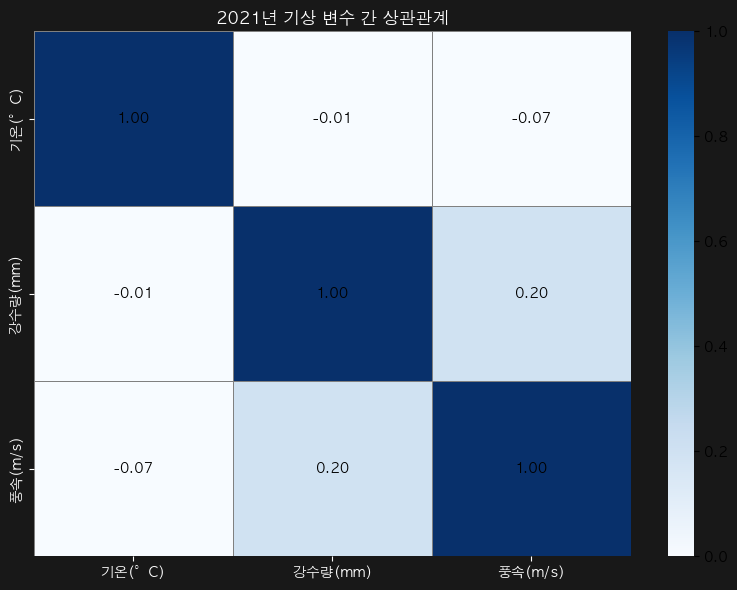

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정 
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'

# ✅ 다크 테마 스타일 적용 + 블루 계열, 밝은 숫자, 어두운 배경
plt.figure(figsize=(8, 6), facecolor='#181818')
ax = sns.heatmap(
    weather_21[['기온(°C)', '강수량(mm)', '풍속(m/s)']].corr(),
    annot=True,
    fmt=".2f",
    cmap='Blues',              # ✅ 같은 계열 그라데이션
    vmin=0, vmax=1,            # ✅ 양의 상관관계만 강조
    annot_kws={"color": "black"},  # ✅ 숫자는 검정
    linewidths=0.5,
    linecolor='gray'
)

# ✅ 스타일 통일
ax.set_facecolor('#181818')                     # 안쪽 배경
plt.title('2021년 기상 변수 간 상관관계', color='white')  # 제목 색
ax.tick_params(axis='both', colors='white')     # 눈금 색
plt.tight_layout()
plt.show()

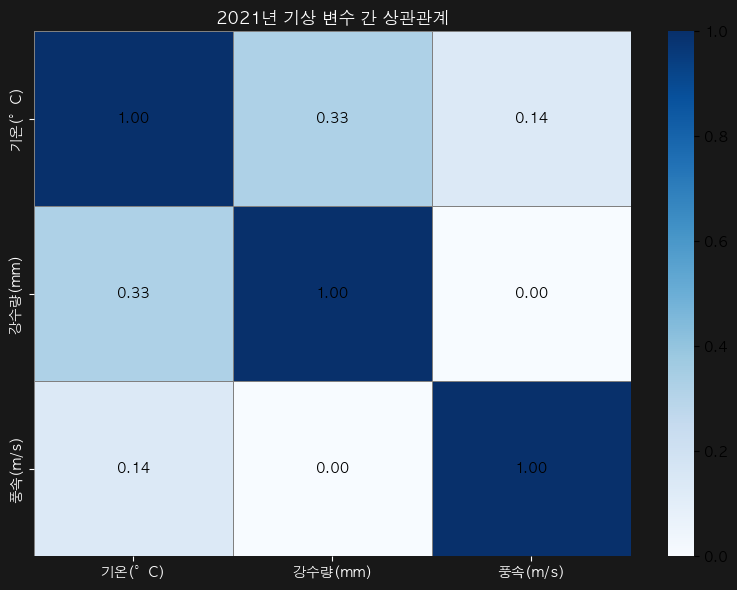

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정 
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'

# ✅ 다크 테마 스타일 적용 + 블루 계열, 밝은 숫자, 어두운 배경
plt.figure(figsize=(8, 6), facecolor='#181818')
ax = sns.heatmap(
    weather_22[['기온(°C)', '강수량(mm)', '풍속(m/s)']].corr(),
    annot=True,
    fmt=".2f",
    cmap='Blues',              # ✅ 같은 계열 그라데이션
    vmin=0, vmax=1,            # ✅ 양의 상관관계만 강조
    annot_kws={"color": "black"},  # ✅ 숫자는 검정
    linewidths=0.5,
    linecolor='gray'
)

# ✅ 스타일 통일
ax.set_facecolor('#181818')                     # 안쪽 배경
plt.title('2021년 기상 변수 간 상관관계', color='white')  # 제목 색
ax.tick_params(axis='both', colors='white')     # 눈금 색
plt.tight_layout()
plt.show()

In [66]:
# 시각화를 통해 알게된 사실을 정리해봅니다.
# 1. 월별 기후 변화를 확인
# 2. PM10 농도가 높은 날에 풍속이 높았음을 알 수 있음
# 3. 봄철 중 강수량이 제일 적은 5월에 PM10이 제일 높음을 확인할 수 있음